In [34]:
from qiskit import *
from qiskit.visualization import plot_bloch_multivector
%matplotlib inline

# A B | S C
# 0 0 | 0 0
# 0 1 | 1 0
# 1 0 | 1 0
# 1 1 | 0 1

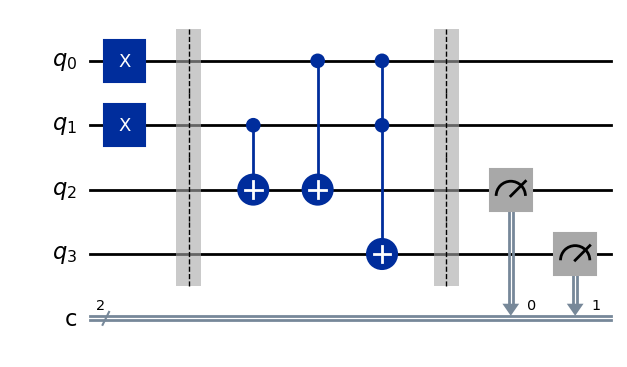

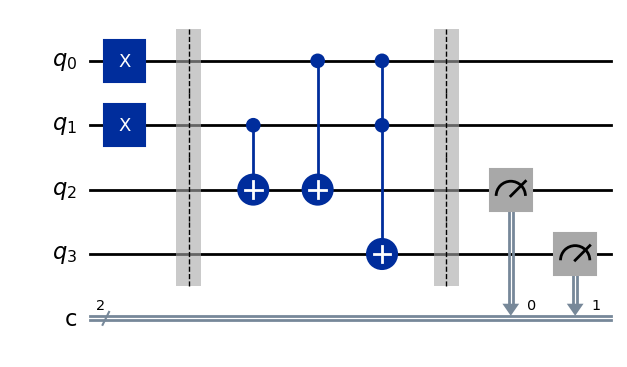

In [35]:
circuit = QuantumCircuit(4, 2)
circuit.x(0) # initalize input A
circuit.x(1) # initalize input B
circuit.barrier()

circuit.cx(1,2)
circuit.cx(0,2)
circuit.ccx(0,1,3)

circuit.barrier()
circuit.measure(2, 0) # measure SUM
circuit.measure(3, 1) # measure CARRY-OUT
circuit.draw(output='mpl')

In [36]:
# UPDATE: Code updated after recording to resolve breaking changes from Qiskit 1.0
from qiskit.providers.basic_provider import BasicProvider
simulator = BasicProvider().get_backend('basic_simulator')
compiled_circuit = transpile(circuit, simulator)
result = simulator.run(compiled_circuit, shots=1).result()
counts = result.get_counts()
print(f'SUM is {list(counts.keys())[0][1]}')
print(f'CARRY-OUT is {list(counts.keys())[0][0]}')

SUM is 0
CARRY-OUT is 1


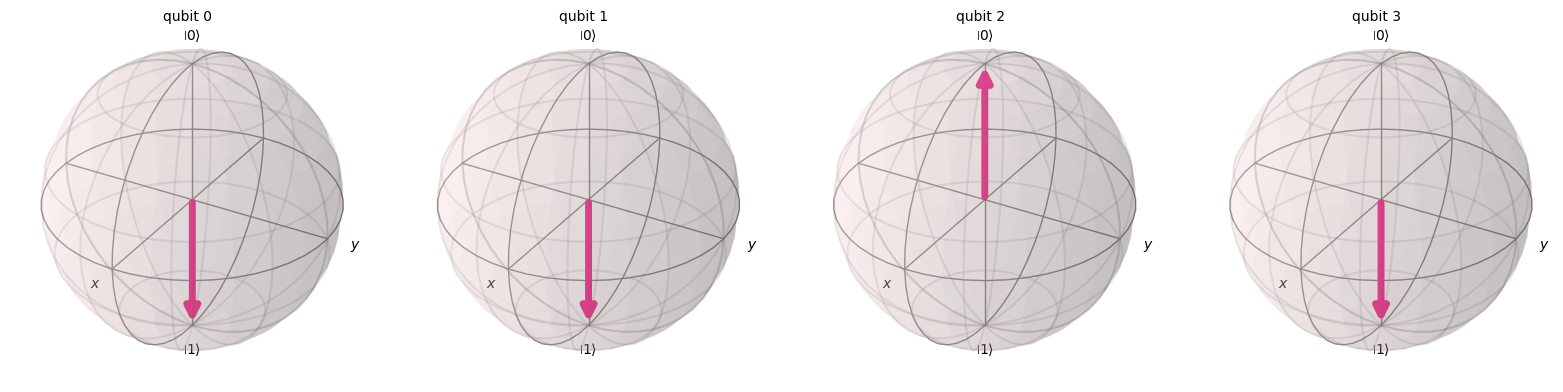

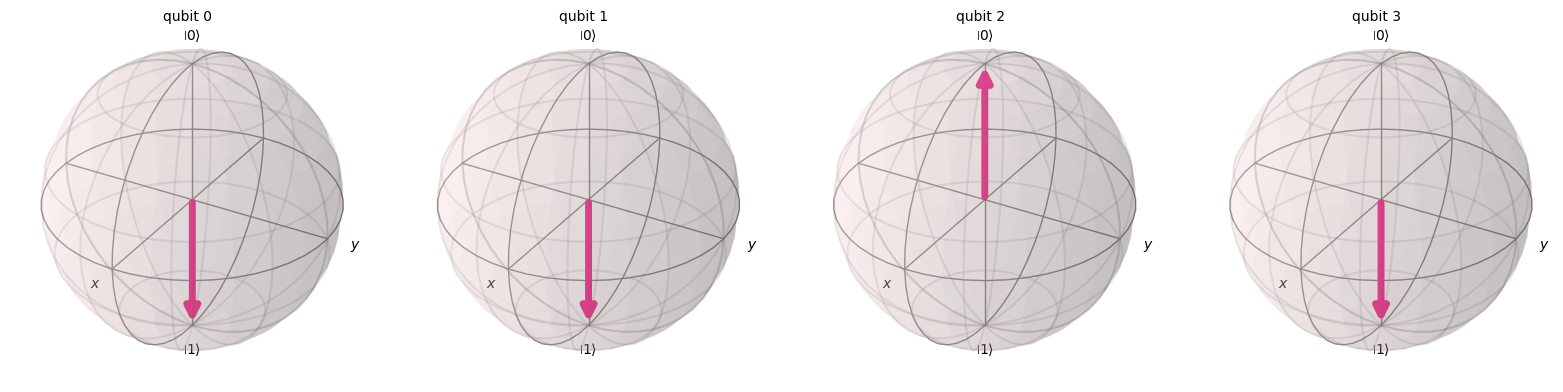

In [37]:
circuit.remove_final_measurements()
from qiskit.quantum_info import Statevector
statevector = Statevector(circuit)
plot_bloch_multivector(statevector)